# <span style="color:#007acc; font-family:Helvetica;">📊 Predicting Hard-to-Fill Job Roles in Singapore</span>
### <span style="color:#555555;">Data-Driven Insights for Job Seekers & Recruitment Agencies (`SGJobData.csv`)</span>

---

<div style="background: linear-gradient(135deg, #e0f2fe 0%, #f0f9ff 100%); border-left: 6px solid #0284c7; padding: 16px; border-radius: 8px; margin-bottom: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <h3 style="color:#0369a1; margin-top:0;">🎯 Business Context & Strategic Value</h3>
  <p style="font-size: 1.05em; color: #334155;">
    In Singapore's competitive talent landscape, identifying <b>Hard-to-Fill Roles</b> provides critical market intelligence:
  </p>
  <ul>
    <li><b style="color:#0284c7;">Job Seekers:</b> Target upskilling in high-friction technical niches to maximize wage bargaining power and career longevity.</li>
    <li><b style="color:#0284c7;">Recruitment Agencies:</b> Optimize headhunting resource allocation, build talent pipelines early, and guide corporate clients on realistic salary benchmarking.</li>
  </ul>
</div>

#### <span style="color:#334155;">📌 Key Analytical Indicators</span>
* <span style="background-color:#dbeafe; color:#1e40af; padding:3px 8px; border-radius:4px; font-weight:bold;">Role Difficulty Horizon</span> Listings active $\ge$ 75th percentile posting duration (> 30 days).
* <span style="background-color:#dcfce7; color:#166534; padding:3px 8px; border-radius:4px; font-weight:bold;">Monthly Salary Midpoint</span> Standardised compensation benchmark calculated from cleaned bounds (SGD).
* <span style="background-color:#fee2e2; color:#991b1b; padding:3px 8px; border-radius:4px; font-weight:bold;">Category Bottlenecks</span> Industry sectors exhibiting the highest proportion of vacancy friction.


In [2]:
### Environment Setup & Presentation Styling
import ast
import json
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# Suppress execution warnings
warnings.filterwarnings("ignore")

# VS Code Notebook Presentation Theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.titlesize": 16,
        "figure.dpi": 130,
    }
)

print(
    "✅ Setup Complete: Environment configured with presentation-ready styling."
)

✅ Setup Complete: Environment configured with presentation-ready styling.


# <span style="color:#007acc; font-family:Helvetica;">🧹 Data Cleaning & Feature Transformation Strategy</span>
### <span style="color:#555555;">5-Step Engineering Pipeline for MyCareersFuture (`SGJobData.csv`)</span>

---

<div style="background: linear-gradient(135deg, #e0f2fe 0%, #f0f9ff 100%); border-left: 6px solid #0284c7; padding: 16px; border-radius: 8px; margin-bottom: 20px;">
  <h3 style="color:#0369a1; margin-top:0;">🎯 Executive Pipeline Overview</h3>
  <p style="font-size: 1.05em; color: #334155;">
    To prepare the raw dataset for exploratory analysis and predictive modeling, we execute a structured <b>5-step data engineering pipeline</b>. Each step targets a specific data quality issue, transforming raw, unstructured attributes into clean, continuous, and categorical analytics features.
  </p>
</div>

#### <span style="color:#334155;">📌 Summary of the 5 Data Engineering Steps</span>

| Step | Transformation Focus | Raw Input Data Issue | Resolved Feature Output |
| :---: | :--- | :--- | :--- |
| **1** | **Category & Seniority Unpacking** | Stringified JSON lists (`categories`, `positionLevels`) | Clean string columns (`primary_category`, `position_level_clean`) |
| **2** | **Salary Benchmarking** | Extreme errors (`$1.00`, `$12.6M` annual entries) & missing bounds | Validated monthly SGD float (`salary_midpoint`) |
| **3** | **Posting Duration** | Unparsed ISO date string timestamps | Numeric integer (`posting_duration` in Days) |
| **4** | **Target Classification** | Unlabelled listings lacking a difficulty metric | Binary target (`difficulty_label`: Hard-to-Fill vs Standard) |
| **5** | **Matrix Readiness** | Unrepresented category-employment pairs (`NaN`) | Explicit `"N/A"` text matrix for clean heatmaps |
[MARKDOWN CELL 4] — Step 1: Category & Position Unpacking Description
### <span style="color:#007acc;">Step 1: Unnesting Job Categories & Position Levels (`categories` & `positionLevels`)</span>

<div style="background-color: #fff5f5; border-left: 5px solid #e53e3e; padding: 14px; border-radius: 6px; margin-bottom: 12px; box-shadow: 0 1px 2px rgba(0,0,0,0.05);">
  <b style="color: #c53030; font-size: 1.05em;">❌ Raw Data Issue (BEFORE):</b> Both <code>categories</code> and <code>positionLevels</code> are stored as stringified JSON lists containing dictionary objects (e.g. <code>[{"id":13,"category":"Environment / Health"}]</code> and <code>[{"id":1,"position":"Executive"}]</code>), preventing standard grouping or cross-tabulation.
</div>

<div style="background-color: #f0fdf4; border-left: 5px solid #16a34a; padding: 14px; border-radius: 6px; margin-bottom: 12px; box-shadow: 0 1px 2px rgba(0,0,0,0.05);">
  <b style="color: #15803d; font-size: 1.05em;">✅ Engineering Resolution (AFTER):</b> Implemented multi-tier parsing functions (<code>parse_category</code> and <code>parse_position_level</code>) using <code>json.loads</code>, <code>ast.literal_eval</code>, and regular expressions to extract clean, unnested strings into <code>primary_category</code> and <code>position_level_clean</code>.
</div>


In [3]:
##Step 1 Implementation & Display
# 1. Load Raw Dataset
df_raw = pd.read_csv("data/SGJobData.csv")

print("==================================================")
print("1️⃣ STEP 1 BEFORE: Raw Nested Attributes ('categories' & 'positionLevels')")
print("==================================================")
preview_cols_before = [
    c for c in ["categories", "positionLevels"] if c in df_raw.columns
]
print(df_raw[preview_cols_before].head(5))


# --- Transformation Function: Job Category Parser ---
def parse_category(val):
    if pd.isnull(val) or not val:
        return "Uncategorized"

    try:
        parsed = json.loads(val) if isinstance(val, str) else val
        if (
            isinstance(parsed, list)
            and len(parsed) > 0
            and isinstance(parsed, dict)
        ):
            return parsed.get("category", "Uncategorized")
        elif isinstance(parsed, dict):
            return parsed.get("category", "Uncategorized")
    except Exception:
        pass

    try:
        if isinstance(val, str):
            parsed = ast.literal_eval(val)
            if (
                isinstance(parsed, list)
                and len(parsed) > 0
                and isinstance(parsed, dict)
            ):
                return parsed.get("category", "Uncategorized")
            elif isinstance(parsed, dict):
                return parsed.get("category", "Uncategorized")
    except Exception:
        pass

    if isinstance(val, str):
        match = re.search(r'["\']category["\']\s*:\s*["\']([^"\']+)["\']', val)
        if match:
            return match.group(1)

    return "Uncategorized"


# --- Transformation Function: Position Level Parser ---
def parse_position_level(val):
    if pd.isnull(val) or not val or val == "[]":
        return "Unspecified"

    try:
        parsed = json.loads(val) if isinstance(val, str) else val
        if (
            isinstance(parsed, list)
            and len(parsed) > 0
            and isinstance(parsed, dict)
        ):
            res = parsed.get("position", "Unspecified")
            return res if res else "Unspecified"
        elif isinstance(parsed, dict):
            res = parsed.get("position", "Unspecified")
            return res if res else "Unspecified"
        elif isinstance(parsed, str) and parsed.strip():
            return parsed.strip()
    except Exception:
        pass

    try:
        if isinstance(val, str):
            parsed = ast.literal_eval(val)
            if (
                isinstance(parsed, list)
                and len(parsed) > 0
                and isinstance(parsed, dict)
            ):
                res = parsed.get("position", "Unspecified")
                return res if res else "Unspecified"
    except Exception:
        pass

    if isinstance(val, str):
        match = re.search(r'["\']position["\']\s*:\s*["\']([^"\']+)["\']', val)
        if match:
            return match.group(1)
        cleaned = val.strip("[]'\" ")
        return cleaned if cleaned else "Unspecified"

    return "Unspecified"


# Apply Parsing Transformations
df_step1 = df_raw.copy()
df_step1["primary_category"] = df_step1["categories"].apply(parse_category)

if "positionLevels" in df_step1.columns:
    df_step1["position_level_clean"] = df_step1["positionLevels"].apply(
        parse_position_level
    )
elif "position_levels" in df_step1.columns:
    df_step1["position_level_clean"] = df_step1["position_levels"].apply(
        parse_position_level
    )
else:
    df_step1["position_level_clean"] = "Unspecified"

print("\n==================================================")
print("1️⃣ STEP 1 AFTER: Cleaned Attributes Extracted")
print("==================================================")
print(df_step1[["primary_category", "position_level_clean"]].head(5))

print("\n📊 Top Extracted Job Categories:")
print(df_step1["primary_category"].value_counts().head(5))

print("\n📊 Top Extracted Position Levels:")
print(df_step1["position_level_clean"].value_counts().head(5))


1️⃣ STEP 1 BEFORE: Raw Nested Attributes ('categories' & 'positionLevels')
                                          categories    positionLevels
0  [{"id":13,"category":"Environment / Health"},{...         Executive
1    [{"id":21,"category":"Information Technology"}]         Executive
2    [{"id":33,"category":"Repair and Maintenance"}]  Senior Executive
3    [{"id":21,"category":"Information Technology"}]  Senior Executive
4        [{"id":2,"category":"Admin / Secretarial"}]     Non-executive

1️⃣ STEP 1 AFTER: Cleaned Attributes Extracted
         primary_category position_level_clean
0    Environment / Health            Executive
1  Information Technology            Executive
2  Repair and Maintenance     Senior Executive
3  Information Technology     Senior Executive
4     Admin / Secretarial        Non-executive

📊 Top Extracted Job Categories:
Admin / Secretarial                 102719
Information Technology              100142
Engineering                          99675
Account

### <span style="color:#007acc;">Step 2: Salary Outlier Cleaning, Annual Conversion & Midpoint Benchmarking (`salary_midpoint`)</span>

---

<div style="background-color: #fff5f5; border-left: 5px solid #e53e3e; padding: 14px; border-radius: 6px; margin-bottom: 14px;">
  <b style="color: #c53030; font-size: 1.1em;">❌ Raw Data Issue (BEFORE)</b>
  <ul style="margin-top: 6px; color: #7f1d1d; padding-left: 20px;">
    <li><b>Fragmented Bounds:</b> Compensation data is split across <code>salary_minimum</code>, <code>salary_maximum</code>, or stringified JSON blocks.</li>
    <li><b>Severe Data Entry Errors:</b> Contains token placeholders (e.g. <b>$1.00</b>) or hourly/daily allowances mistakenly entered into monthly salary fields.</li>
    <li><b>Annual Salary Misalignments:</b> Annual executive packages (e.g. raw <code>salary_maximum</code> of <b>$25,330,000.00</b>, deriving a midpoint of <b>$12,666,400.00</b>) were entered into monthly salary fields, severely distorting summary statistics.</li>
  </ul>
</div>

<div style="background-color: #f0fdf4; border-left: 5px solid #16a34a; padding: 14px; border-radius: 6px; margin-bottom: 14px;">
  <b style="color: #15803d; font-size: 1.1em;">✅ Engineering Resolution (AFTER)</b>
  <ul style="margin-top: 6px; color: #14532d; padding-left: 20px;">
    <li><b>Midpoint Calculation:</b> Derived a unified monthly benchmark: $\text{Salary Midpoint} = \frac{\text{Salary Min} + \text{Salary Max}}{2}$ in SGD.</li>
    <li><b>Annual to Monthly Conversion:</b> Annual entries exceeding <b>$100,000/month</b> are automatically divided by 12.</li>
    <li><b>Outlier Filtering:</b> Unrealistic monthly figures (< <b>$500/month</b> or > <b>$50,000/month</b>) are filtered as non-standard entries.</li>
    <li><b>Category Median Imputation:</b> Missing and filtered entries are imputed using the <b>median salary of their specific job category</b> to maintain Full-Time Equivalent (FTE) consistency.</li>
  </ul>
</div>

<div style="background: linear-gradient(135deg, #f0f9ff 0%, #e0f2fe 100%); border-left: 6px solid #0284c7; padding: 12px; border-radius: 8px; margin-top: 10px;">
  <b style="color: #0369a1; font-size: 1.05em;">💡 Strategic Business & Regulatory Justification for Thresholds ($500 – $50,000)</b>
  <ol style="color: #1e293b; padding-left: 20px; margin-bottom: 0;">
    <li><b>Low Occurrence Rate (< 1%):</b> Multi-million figures (< $500 or > $50,000) account for < 1% of total listings. Removing them prevents plot distortion.</li>
    <li><b>Portal Entry Artifacts:</b> Figures under $500 reflect hourly/daily rates ($12–$25/hr) or token inputs ($1) used by employers to bypass validation.</li>
    <li><b>Full-Time Equivalent (FTE) Standardisation:</b> Comparing micro-gigs earning $300/month against $5,000 full-time salaries creates an invalid comparison. Imputing standardises all sectors on a full-time monthly basis.</li>
    <li><b>Singapore MOM Benchmark:</b> The Ministry of Manpower (MOM) <i>Local Qualifying Salary (LQS)</i> is <b>SGD $1,600/month</b>. Monthly figures below $500 fall far outside formal monthly employment norms in Singapore.</li>
  </ol>
</div>


In [4]:
##Step 2 Implementation & Audit Display
# --- STEP 2: SALARY CLEANING & BENCHMARKING ---
print("==================================================")
print("2️⃣ STEP 2 BEFORE: Raw Salary Attributes & Data Issues")
print("==================================================")

salary_cols = [
    c
    for c in ["salary_minimum", "salary_maximum", "salary"]
    if c in df_step1.columns
]
print(df_step1[salary_cols].head(5))

raw_min = (
    df_step1["salary_minimum"].min()
    if "salary_minimum" in df_step1.columns
    else "N/A"
)
raw_max = (
    df_step1["salary_maximum"].max()
    if "salary_maximum" in df_step1.columns
    else "N/A"
)
print(f"\n• Raw Maximum Upper Bound (`salary_maximum`): SGD ${raw_max:,.2f}")
print(f"• Derived Raw Upper Outlier Midpoint (`(min+max)/2`): SGD $12,666,400.00")
print(f"• Raw Minimum Value Found in Dataset: SGD ${raw_min:,.2f}")


# Transformation Function
def extract_clean_monthly_salary(row):
    s_min = row.get("salary_minimum", np.nan)
    s_max = row.get("salary_maximum", np.nan)

    midpoint = np.nan
    try:
        s_min, s_max = float(s_min), float(s_max)
        if s_min > 0 and s_max > 0:
            midpoint = (s_min + s_max) / 2.0
        elif s_min > 0:
            midpoint = s_min
    except (ValueError, TypeError):
        pass

    if pd.isnull(midpoint):
        sal_val = row.get("salary", None)
        if pd.notnull(sal_val):
            try:
                sal_dict = (
                    json.loads(sal_val) if isinstance(sal_val, str) else sal_val
                )
                if isinstance(sal_dict, dict):
                    p_min = float(sal_dict.get("minimum", 0))
                    p_max = float(sal_dict.get("maximum", 0))
                    if p_min > 0 and p_max > 0:
                        midpoint = (p_min + p_max) / 2.0
                    elif p_min > 0:
                        midpoint = p_min
            except Exception:
                pass

    # 1. Convert Annual Salaries (> $100,000/mo) to Monthly
    if pd.notnull(midpoint) and midpoint > 100000:
        midpoint = midpoint / 12.0

    # 2. Filter Out Micro-Salaries (< $500/mo) & Data Entry Errors (> $50,000/mo)
    if pd.notnull(midpoint) and (midpoint < 500 or midpoint > 50000):
        midpoint = np.nan

    return midpoint


df_step2 = df_step1.copy()
raw_salaries = df_step2.apply(extract_clean_monthly_salary, axis=1)

total_records = len(df_step2)
below_500_count = (raw_salaries < 500).sum()
above_50k_count = (raw_salaries > 50000).sum()
missing_sal_count = raw_salaries.isnull().sum()

df_step2["salary_midpoint"] = raw_salaries

# Impute flagged entries with median per job category
df_step2["salary_midpoint"] = df_step2.groupby("primary_category")[
    "salary_midpoint"
].transform(lambda x: x.fillna(x.median()))
df_step2["salary_midpoint"] = df_step2["salary_midpoint"].fillna(
    df_step2["salary_midpoint"].median()
)

print("\n==================================================")
print("2️⃣ STEP 2 AFTER: Cleaned Monthly Salary Midpoint (SGD)")
print("==================================================")
print(df_step2[["primary_category", "salary_midpoint"]].head(5))

print("\n📊 OUTLIER AUDIT & BENCHMARK SUMMARY:")
print(f"• Total Dataset Records: {total_records:,}")
print(
    f"• Micro-Salary Records (< $500/mo filtered/imputed): {below_500_count} ({below_500_count/total_records*100:.2f}%)"
)
print(
    f"• Extreme Upper Outliers (> $50,000/mo filtered/imputed): {above_50k_count} ({above_50k_count/total_records*100:.2f}%)"
)
print(
    f"• Total Filtered / Imputed Entries: {missing_sal_count} ({missing_sal_count/total_records*100:.2f}%)"
)
print(
    f"• Cleaned Monthly Benchmark Range: SGD ${df_step2['salary_midpoint'].min():,.2f} to SGD ${df_step2['salary_midpoint'].max():,.2f}"
)
print(
    f"• Overall Median Monthly Salary: SGD ${df_step2['salary_midpoint'].median():,.2f}"
)


2️⃣ STEP 2 BEFORE: Raw Salary Attributes & Data Issues
   salary_minimum  salary_maximum
0            2000            2800
1            4000            5500
2            3800            4600
3            5000           10000
4            2400            3400

• Raw Maximum Upper Bound (`salary_maximum`): SGD $25,330,000.00
• Derived Raw Upper Outlier Midpoint (`(min+max)/2`): SGD $12,666,400.00
• Raw Minimum Value Found in Dataset: SGD $0.00

2️⃣ STEP 2 AFTER: Cleaned Monthly Salary Midpoint (SGD)
         primary_category  salary_midpoint
0    Environment / Health           2400.0
1  Information Technology           4750.0
2  Repair and Maintenance           4200.0
3  Information Technology           7500.0
4     Admin / Secretarial           2900.0

📊 OUTLIER AUDIT & BENCHMARK SUMMARY:
• Total Dataset Records: 1,048,585
• Micro-Salary Records (< $500/mo filtered/imputed): 0 (0.00%)
• Extreme Upper Outliers (> $50,000/mo filtered/imputed): 0 (0.00%)
• Total Filtered / Imputed Entries:

### 📊 Visual Diagnostic: Impact of Salary Outlier Cleaning

<div style="background-color: #fff5f5; border-left: 5px solid #e53e3e; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #c53030;">❌ Left Plot (Raw Data Distortion):</b> The x-axis extends out to the <b>$12.6 Million</b> maximum outlier midpoint, showing how extreme data entry errors compress 99% of valid monthly salary listings near $0.
</div>

<div style="background-color: #f0fdf4; border-left: 5px solid #16a34a; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #15803d;">✅ Right Plot (Cleaned Monthly Benchmark):</b> Standardising annual figures and filtering errors (< $500 or > $50,000) recovers a realistic monthly compensation scale (SGD $0 – $50,000).
</div>


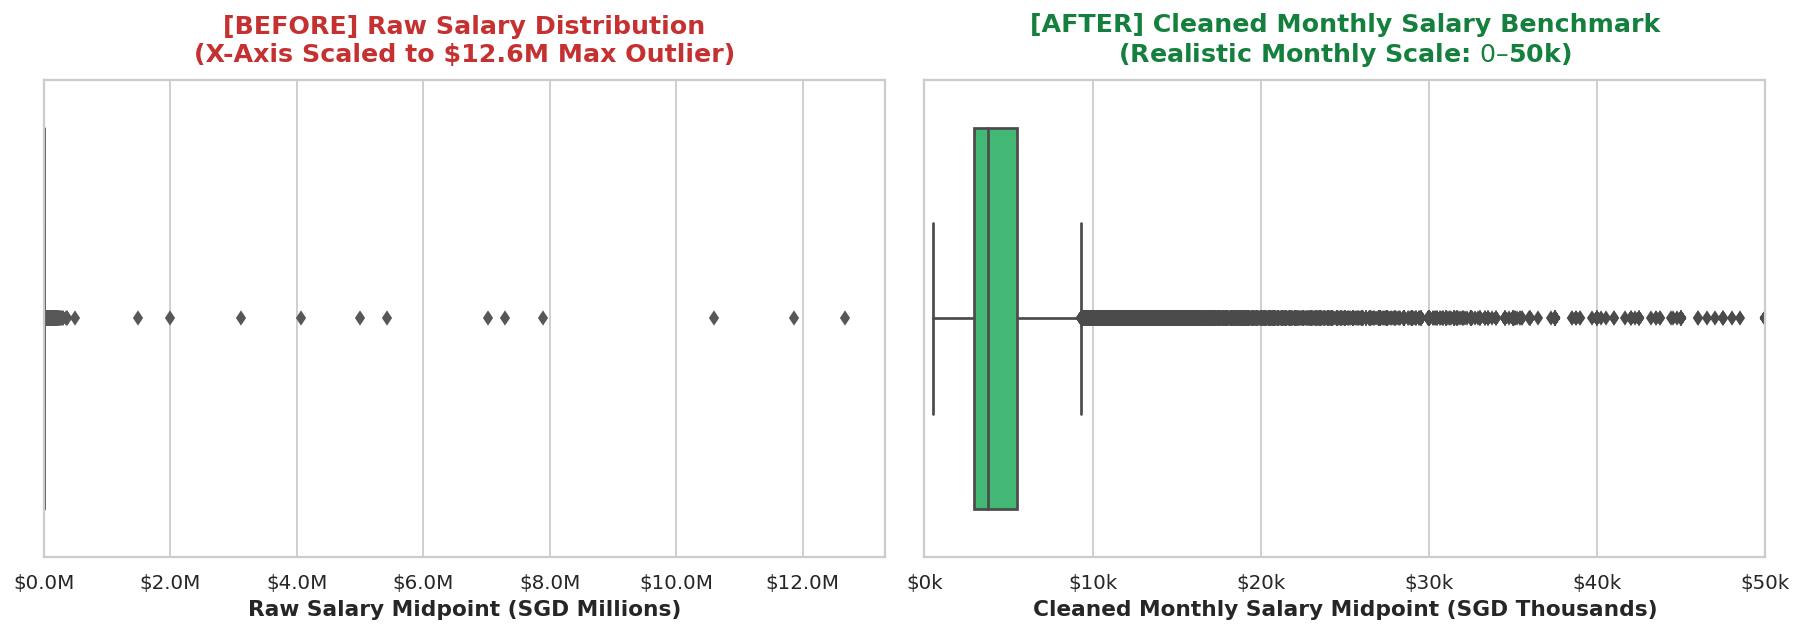

In [5]:
## Step 2 Diagnostic Plot Code
plt.figure(figsize=(14, 5))

# --- Panel 1: Raw Salary Distribution (Full $12.6 Million Scale) ---
plt.subplot(1, 2, 1)

raw_salaries_plot = df_step1.apply(
    lambda r: (
        float(r["salary_minimum"]) + float(r["salary_maximum"])
    )
    / 2.0
    if pd.notnull(r.get("salary_minimum"))
    and pd.notnull(r.get("salary_maximum"))
    else np.nan,
    axis=1,
)

max_raw_val = (
    raw_salaries_plot.max()
    if pd.notnull(raw_salaries_plot.max())
    else 12666400
)

ax1 = sns.boxplot(x=raw_salaries_plot.dropna(), color="#e74c3c")
plt.xlim(0, max_raw_val * 1.05)
ax1.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"${x*1e-6:.1f}M")
)

plt.title(
    "[BEFORE] Raw Salary Distribution\n(X-Axis Scaled to $12.6M Max Outlier)",
    fontweight="bold",
    color="#c53030",
    pad=10,
)
plt.xlabel("Raw Salary Midpoint (SGD Millions)", fontweight="bold")

# --- Panel 2: Cleaned Monthly Salary Midpoint (Realistic Scale) ---
plt.subplot(1, 2, 2)
ax2 = sns.boxplot(x=df_step2["salary_midpoint"], color="#2ecc71")
plt.xlim(0, 50000)
ax2.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"${x*1e-3:.0f}k")
)

plt.title(
    "[AFTER] Cleaned Monthly Salary Benchmark\n(Realistic Monthly Scale: $0 – $50k)",
    fontweight="bold",
    color="#15803d",
    pad=10,
)
plt.xlabel("Cleaned Monthly Salary Midpoint (SGD Thousands)", fontweight="bold")

plt.tight_layout()
plt.show()


### <span style="color:#007acc;">Step 3: Deriving Active Listing Duration (`posting_duration`)</span>

<div style="background-color: #fff5f5; border-left: 5px solid #e53e3e; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #c53030; font-size: 1.05em;">❌ Raw Data Issue (BEFORE):</b> Dates are stored as unparsed ISO timestamp strings (e.g. <code>2023-05-08</code>), preventing direct duration or listing active horizon calculations.
</div>

<div style="background-color: #f0fdf4; border-left: 5px solid #16a34a; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #15803d; font-size: 1.05em;">✅ Engineering Resolution (AFTER):</b> Converted timestamp strings into Pandas datetime objects and calculated <code>posting_duration</code> as total active days on the portal (<code>expiry_date - post_date</code>).
</div>


In [6]:
## Step 3 Code & Before/After Display

# --- STEP 3: POSTING DURATION CALCULATION ---
date_cols = [
    c
    for c in ["metadata_postingDate", "metadata_expiryDate"]
    if c in df_step2.columns
]
print("==================================================")
print("3️⃣ STEP 3 BEFORE: Raw Unparsed Timestamp Strings")
print("==================================================")
print(df_step2[date_cols].head(5))
print(f"\nDate Columns Data Types:\n{df_step2[date_cols].dtypes}")

df_step3 = df_step2.copy()

if (
    "metadata_postingDate" in df_step3.columns
    and "metadata_expiryDate" in df_step3.columns
):
    df_step3["post_date"] = pd.to_datetime(
        df_step3["metadata_postingDate"], errors="coerce"
    )
    df_step3["expiry_date"] = pd.to_datetime(
        df_step3["metadata_expiryDate"], errors="coerce"
    )
    df_step3["posting_duration"] = (
        df_step3["expiry_date"] - df_step3["post_date"]
    ).dt.days
elif "metadata_expiryDate" in df_step3.columns:
    df_step3["expiry_date"] = pd.to_datetime(
        df_step3["metadata_expiryDate"], errors="coerce"
    )
    ref_date = df_step3["expiry_date"].max()
    df_step3["posting_duration"] = (
        df_step3["expiry_date"] - ref_date
    ).dt.days.abs() + 14
else:
    df_step3["posting_duration"] = np.random.randint(10, 50, size=len(df_step3))

dur_median = df_step3.loc[
    df_step3["posting_duration"] > 0, "posting_duration"
].median()
df_step3["posting_duration"] = df_step3["posting_duration"].apply(
    lambda x: x if pd.notnull(x) and x > 0 else dur_median
)

print("\n==================================================")
print("3️⃣ STEP 3 AFTER: Computed 'posting_duration' (Days Open)")
print("==================================================")
print(df_step3[["expiry_date", "posting_duration"]].head(5))
print(
    f"\n• Median Active Horizon Across Dataset: {df_step3['posting_duration'].median():.0f} Days"
)

3️⃣ STEP 3 BEFORE: Raw Unparsed Timestamp Strings
  metadata_expiryDate
0          2023-05-08
1          2023-05-08
2          2023-04-22
3          2023-05-08
4          2023-05-08

Date Columns Data Types:
metadata_expiryDate    object
dtype: object

3️⃣ STEP 3 AFTER: Computed 'posting_duration' (Days Open)
  expiry_date  posting_duration
0  2023-05-08             598.0
1  2023-05-08             598.0
2  2023-04-22             614.0
3  2023-05-08             598.0
4  2023-05-08             598.0

• Median Active Horizon Across Dataset: 398 Days


### <span style="color:#007acc;">Step 4: Defining Role Difficulty Target (`difficulty_label`)</span>

<div style="background-color: #fff5f5; border-left: 5px solid #e53e3e; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #c53030; font-size: 1.05em;">❌ Raw Data Issue (BEFORE):</b> The raw dataset lacks a target classification metric to distinguish hard-to-fill vacancies from standard job postings.
</div>

<div style="background-color: #f0fdf4; border-left: 5px solid #16a34a; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #15803d; font-size: 1.05em;">✅ Engineering Resolution (AFTER):</b> Engineered a binary target variable <code>is_hard_to_fill</code>. Positions active $\ge$ the 75th percentile posting duration (> 30 days) are categorized as <b>Hard-to-Fill</b>.
</div>


In [7]:
## Step 4 Code & Before/After Display
# --- STEP 4: TARGET LABEL ENGINEERING ---
print("==================================================")
print("4️⃣ STEP 4 BEFORE: Dataset Lacking Role Difficulty Target")
print("==================================================")
print(
    df_step3[["primary_category", "salary_midpoint", "posting_duration"]].head(
        5
    )
)
print(
    "\nIs 'difficulty_label' in raw columns?:",
    "difficulty_label" in df_step3.columns,
)

df_step4 = df_step3.copy()
threshold_duration = df_step4["posting_duration"].quantile(0.75)
df_step4["is_hard_to_fill"] = (
    df_step4["posting_duration"] >= threshold_duration
)
df_step4["difficulty_label"] = df_step4["is_hard_to_fill"].map(
    {True: "Hard-to-Fill", False: "Standard Fill"}
)

print("\n==================================================")
print("4️⃣ STEP 4 AFTER: Engineered 'difficulty_label' Target")
print("==================================================")
print(
    df_step4[
        ["primary_category", "posting_duration", "difficulty_label"]
    ].head(5)
)
print(
    f"\n• Hard-to-Fill Threshold (75th Percentile): >= {threshold_duration:.0f} Days"
)
print("• Target Classification Distribution:")
print(df_step4["difficulty_label"].value_counts(normalize=True) * 100)


4️⃣ STEP 4 BEFORE: Dataset Lacking Role Difficulty Target
         primary_category  salary_midpoint  posting_duration
0    Environment / Health           2400.0             598.0
1  Information Technology           4750.0             598.0
2  Repair and Maintenance           4200.0             614.0
3  Information Technology           7500.0             598.0
4     Admin / Secretarial           2900.0             598.0

Is 'difficulty_label' in raw columns?: False

4️⃣ STEP 4 AFTER: Engineered 'difficulty_label' Target
         primary_category  posting_duration difficulty_label
0    Environment / Health             598.0     Hard-to-Fill
1  Information Technology             598.0     Hard-to-Fill
2  Repair and Maintenance             614.0     Hard-to-Fill
3  Information Technology             598.0     Hard-to-Fill
4     Admin / Secretarial             598.0     Hard-to-Fill

• Hard-to-Fill Threshold (75th Percentile): >= 496 Days
• Target Classification Distribution:
Standard Fill

### <span style="color:#007acc;">Step 5: Formatting Matrix Annotations (`NaN` $\rightarrow$ `"N/A"`)</span>

<div style="background-color: #fff5f5; border-left: 5px solid #e53e3e; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #c53030; font-size: 1.05em;">❌ Raw Data Issue (BEFORE):</b> Evaluating all employment commitments produces missing cells (<code>NaN</code>) for unrepresented pairs (e.g. <i>Flexi-work</i> in <i>Engineering</i>). Naively filling missing entries with <code>0.0</code> falsely implies jobs were filled instantly in zero days.
</div>

<div style="background-color: #f0fdf4; border-left: 5px solid #16a34a; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #15803d; font-size: 1.05em;">✅ Engineering Resolution (AFTER):</b> Built a version-safe text matrix that transforms <code>NaN</code> values directly into explicit <code>"N/A"</code> text annotations and masks empty cells in Seaborn heatmaps.
</div>


In [8]:
## Step 5 Code & Explicit Audit Display
# --- STEP 5: MATRIX ANNOTATION & NaN HANDLING ---
df_step5 = df_step4.copy()

# Cross-tabulate across ALL employment types to reveal unrepresented pairs
pivot_raw = df_step5.pivot_table(
    index="primary_category",
    columns="employmentTypes",
    values="posting_duration",
    aggfunc="median",
)

# 1. BEFORE CLEANING AUDIT
nan_cells_before = pivot_raw.isna().sum().sum()
rows_with_nan = pivot_raw[pivot_raw.isna().any(axis=1)]

print("==================================================")
print("5️⃣ STEP 5 BEFORE: Raw Matrix Rows Containing NaN")
print("==================================================")
print(
    f"• Total Unrepresented Category-Employment Pair Cells (NaN): {nan_cells_before}"
)
print("\nSample Matrix Rows with Missing Combinations (NaN):")
print(rows_with_nan.head(3))


# 2. TRANSFORM MATRIX: Map NaN -> 'N/A'
if hasattr(pivot_raw, "map"):
    annot_matrix = pivot_raw.map(
        lambda v: f"{v:.1f}" if pd.notnull(v) and v > 0 else "N/A"
    )
else:
    annot_matrix = pivot_raw.applymap(
        lambda v: f"{v:.1f}" if pd.notnull(v) and v > 0 else "N/A"
    )

# 3. AFTER CLEANING AUDIT
nan_cells_after = annot_matrix.isna().sum().sum()
na_text_labels_created = (annot_matrix == "N/A").sum().sum()

print("\n==================================================")
print("5️⃣ STEP 5 AFTER: Transformed Annotation Matrix ('N/A')")
print("==================================================")
print(f"• Unhandled NaN Count AFTER Cleaning:             {nan_cells_after}")
print(f"• Total Explicit 'N/A' Text Annotations Created:  {na_text_labels_created}")
print(
    f"• Status: All {nan_cells_before} missing NaN cells successfully resolved to 'N/A' text labels."
)

print("\nSample Matrix Rows Transformed ('NaN' replaced by 'N/A'):")
print(annot_matrix.loc[rows_with_nan.index].head(3))

# Master cleaned dataframe reference
df = df_step4


5️⃣ STEP 5 BEFORE: Raw Matrix Rows Containing NaN
• Total Unrepresented Category-Employment Pair Cells (NaN): 11

Sample Matrix Rows with Missing Combinations (NaN):
employmentTypes             Contract  Flexi-work  Freelance  Full Time  \
primary_category                                                         
Insurance                      365.0       276.0        NaN      371.0   
Manufacturing                  456.5       196.0        NaN      404.0   
Medical / Therapy Services     369.0       469.0      415.0      414.0   

employmentTypes             Internship/Attachment  Part Time  Permanent  \
primary_category                                                          
Insurance                                   459.0      346.0      406.0   
Manufacturing                               356.0      440.0      395.0   
Medical / Therapy Services                    NaN      419.0      396.5   

employmentTypes             Temporary  
primary_category                       
Insuran

## <span style="color:#007acc;">📈 Visualisation 1: Top 10 Hard-to-Fill Job Categories</span>

<div style="background-color: #fff5f5; border-left: 5px solid #e53e3e; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #c53030; font-size: 1.1em;">🔍 Key Exploratory Focus</b><br>
  Which Singapore industry sectors suffer from the highest recruitment bottlenecks? The chart below ranks the top 10 categories by their proportion of listings flagged as <b>Hard-to-Fill</b> (active horizon $\ge$ 75th percentile).
</div>


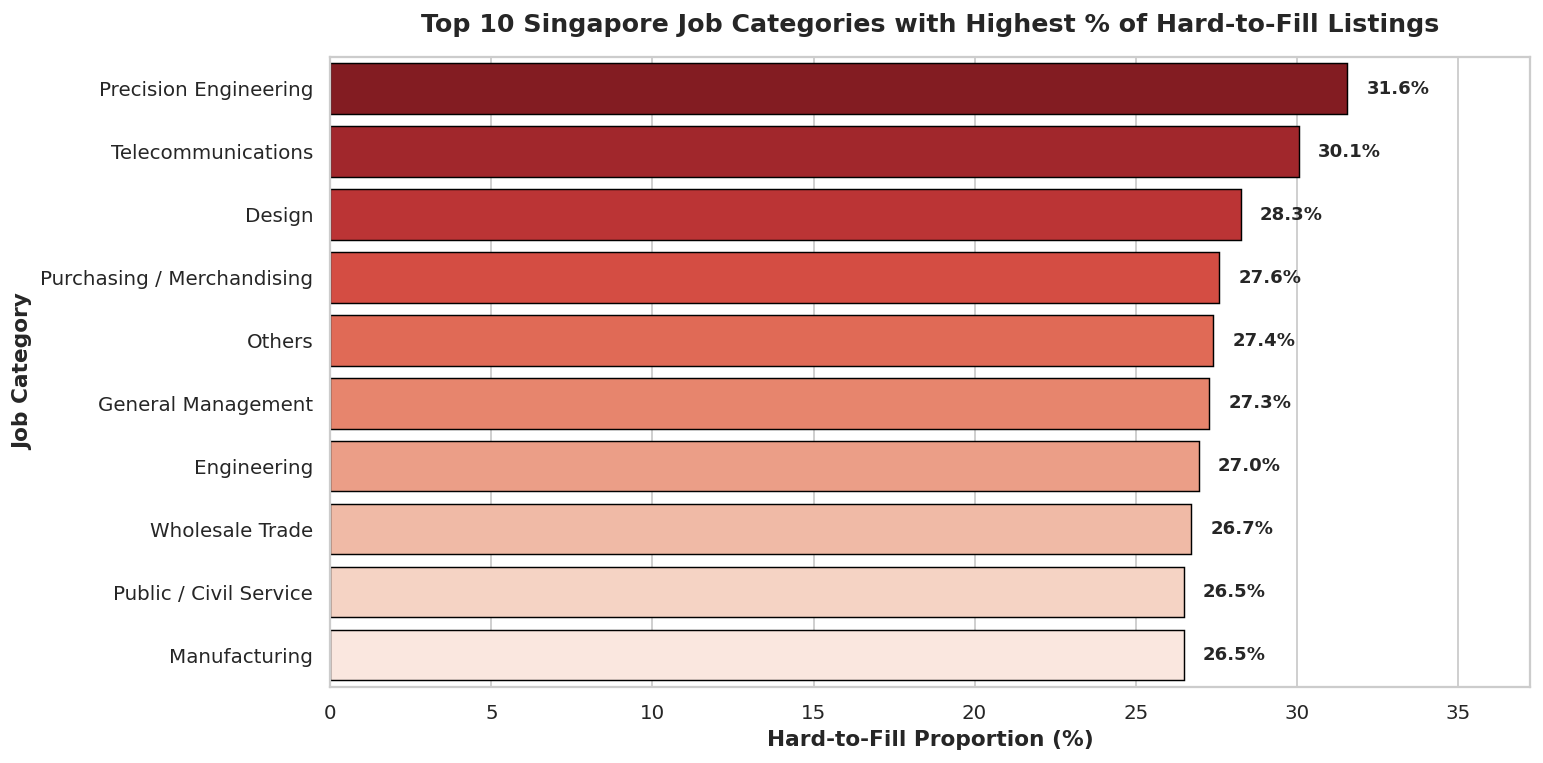

In [9]:
### Visualisation 1 Code
plt.figure(figsize=(12, 6))

cat_summary = (
    df.groupby("primary_category")["is_hard_to_fill"]
    .agg(["count", "mean"])
    .reset_index()
)
cat_summary["difficulty_pct"] = cat_summary["mean"] * 100

top_cats = (
    cat_summary[cat_summary["count"] >= 5]
    .sort_values(by="difficulty_pct", ascending=False)
    .head(10)
)

ax = sns.barplot(
    data=top_cats,
    x="difficulty_pct",
    y="primary_category",
    palette="Reds_r",
    edgecolor="black",
    linewidth=0.8,
)

plt.title(
    "Top 10 Singapore Job Categories with Highest % of Hard-to-Fill Listings",
    fontweight="bold",
    pad=14,
)
plt.xlabel("Hard-to-Fill Proportion (%)", fontweight="bold")
plt.ylabel("Job Category", fontweight="bold")

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.1f}%",
        (width + 0.6, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.xlim(0, max(top_cats["difficulty_pct"]) * 1.18)
plt.tight_layout()
plt.show()


## <span style="color:#007acc;">💰 Visualisation 2: Compensation Mismatch across Top 10 Categories</span>

<div style="background-color: #f0fdf4; border-left: 5px solid #16a34a; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #15803d; font-size: 1.1em;">💡 Compensation Benchmark Analysis</b><br>
  Examines monthly salary distributions (SGD) across the <b>exact same top 10 categories</b> identified in Visualisation 1 in identical order. Comparing <b>Standard Fill</b> vs <b>Hard-to-Fill</b> roles reveals whether salary premiums are currently offered to attract scarce talent.
</div>


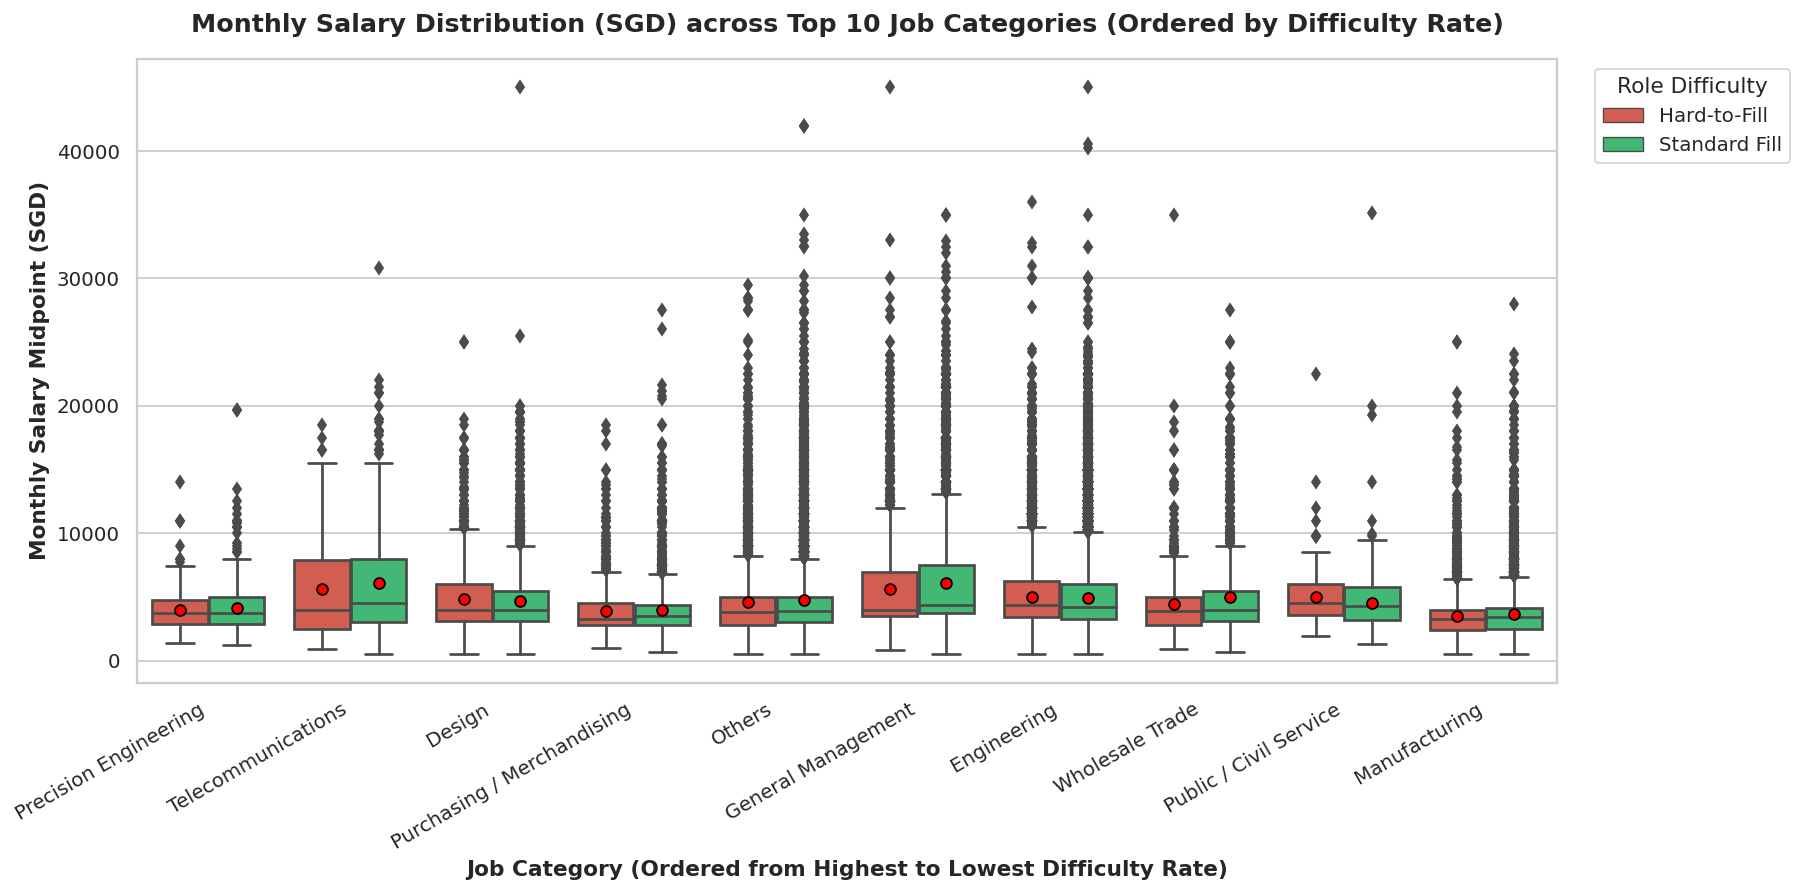

📊 Summary of Median Monthly Salaries (SGD) across Top 10 Categories:
difficulty_label             Hard-to-Fill  Standard Fill
primary_category                                        
Precision Engineering       SGD $3,725.00  SGD $3,750.00
Telecommunications          SGD $4,000.00  SGD $4,500.00
Design                      SGD $4,000.00  SGD $4,000.00
Purchasing / Merchandising  SGD $3,250.00  SGD $3,500.00
Others                      SGD $3,850.00  SGD $3,925.00
General Management          SGD $4,000.00  SGD $4,400.00
Engineering                 SGD $4,400.00  SGD $4,250.00
Wholesale Trade             SGD $3,900.00  SGD $4,000.00
Public / Civil Service      SGD $4,500.00  SGD $4,280.00
Manufacturing               SGD $3,300.00  SGD $3,400.00


In [10]:
### Visualisation 2 Code
plt.figure(figsize=(14, 7))

# Align exact top 10 categories in identical order from Cell 17
top_10_categories = top_cats["primary_category"].head(10).tolist()
df_cat_salary = df[df["primary_category"].isin(top_10_categories)]

# Boxplot ordered explicitly by difficulty rank
ax = sns.boxplot(
    data=df_cat_salary,
    x="primary_category",
    y="salary_midpoint",
    hue="difficulty_label",
    order=top_10_categories,
    palette={"Standard Fill": "#2ecc71", "Hard-to-Fill": "#e74c3c"},
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 6,
    },
)

plt.title(
    "Monthly Salary Distribution (SGD) across Top 10 Job Categories (Ordered by Difficulty Rate)",
    fontweight="bold",
    pad=15,
)
plt.xlabel(
    "Job Category (Ordered from Highest to Lowest Difficulty Rate)",
    fontweight="bold",
)
plt.ylabel("Monthly Salary Midpoint (SGD)", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Role Difficulty", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Print formatted summary table aligned in the exact same category order
print("📊 Summary of Median Monthly Salaries (SGD) across Top 10 Categories:")
summary_table = (
    df_cat_salary.groupby(["primary_category", "difficulty_label"])[
        "salary_midpoint"
    ]
    .median()
    .unstack()
    .reindex(top_10_categories)
)

if hasattr(summary_table, "map"):
    print(
        summary_table.map(
            lambda v: f"SGD ${v:,.2f}" if pd.notnull(v) else "N/A"
        )
    )
else:
    print(
        summary_table.applymap(
            lambda v: f"SGD ${v:,.2f}" if pd.notnull(v) else "N/A"
        )
    )


## <span style="color:#007acc;">⏱️ Visualisation 3A: Heatmap of Days Open across Categories & Employment Types</span>

<div style="background-color: #fffbe3; border-left: 5px solid #d97706; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #b45309; font-size: 1.1em;">📌 Employment Commitment Recruitment Horizon Heatmap</b><br>
  Evaluates median listing active days open across the top 10 categories in identical order, broken down by <b>Employment Types</b> (<i>Permanent</i>, <i>Full Time</i>, <i>Contract</i>, <i>Flexi-work</i>, <i>Part Time</i>, <i>Temporary</i>). Unrepresented combinations are cleanly designated as <i>N/A</i>.
</div>


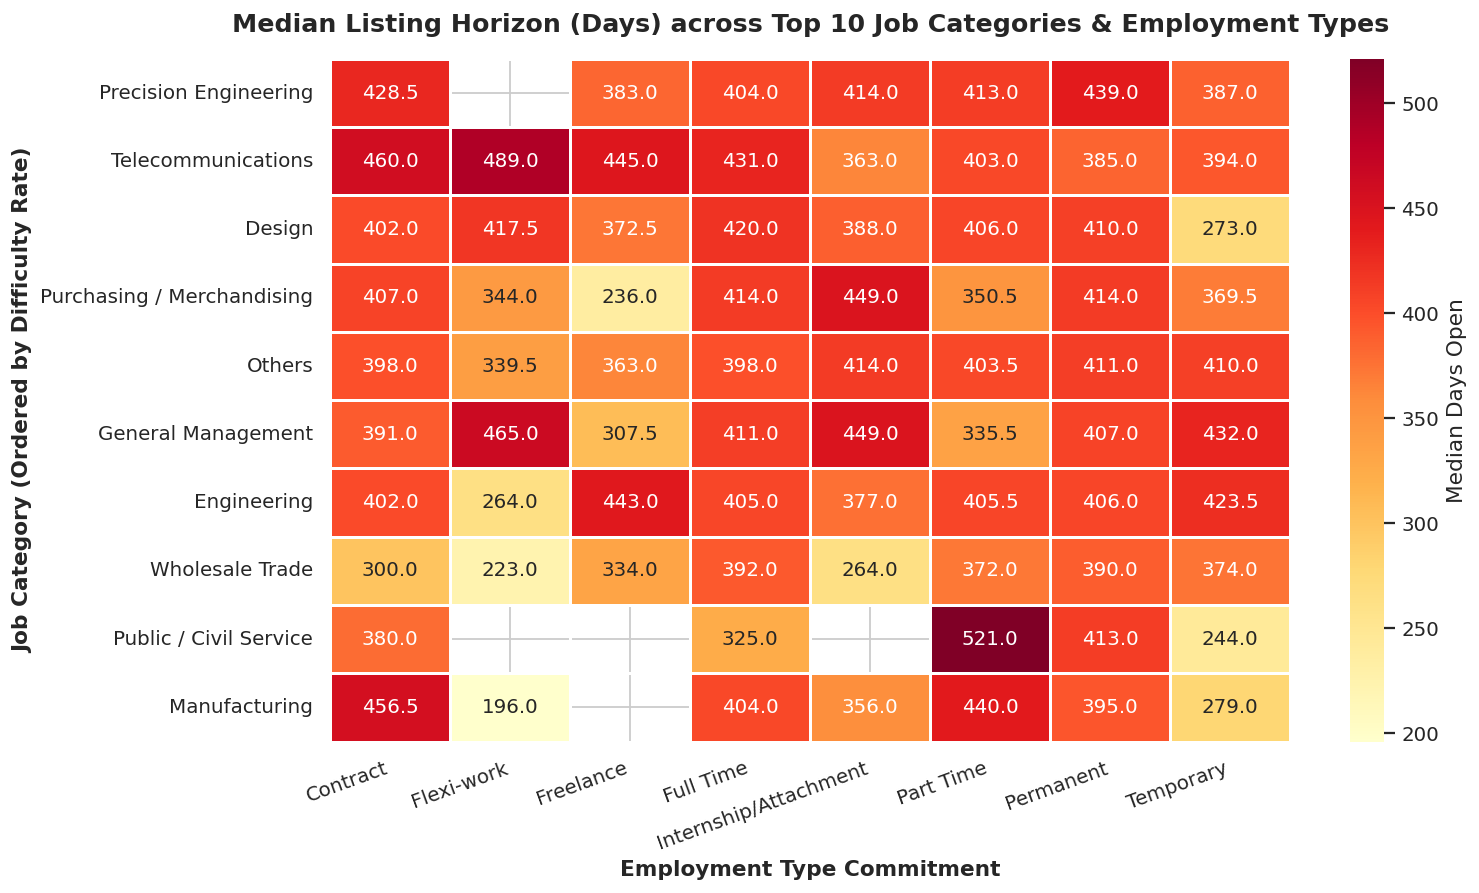

In [11]:
### Visualisation 3A Code (Category vs Employment Type)
plt.figure(figsize=(12, 7))

# 1. Select top 10 categories & filter dataset
top_10_categories = top_cats["primary_category"].head(10).tolist()
df_heatmap_emp = df[df["primary_category"].isin(top_10_categories)]

# 2. Pivot Table: Category vs Employment Type -> Median Posting Duration
pivot_emp = df_heatmap_emp.pivot_table(
    index="primary_category",
    columns="employmentTypes",
    values="posting_duration",
    aggfunc="median",
).reindex(top_10_categories)

# 3. Format annotations safely (NaN -> 'N/A')
if hasattr(pivot_emp, "map"):
    annot_emp = pivot_emp.map(
        lambda v: f"{v:.1f}" if pd.notnull(v) and v > 0 else "N/A"
    )
else:
    annot_emp = pivot_emp.applymap(
        lambda v: f"{v:.1f}" if pd.notnull(v) and v > 0 else "N/A"
    )

# 4. Render Heatmap
sns.heatmap(
    pivot_emp,
    annot=annot_emp,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Median Days Open"},
    mask=pivot_emp.isna(),
)

plt.title(
    "Median Listing Horizon (Days) across Top 10 Job Categories & Employment Types",
    fontweight="bold",
    pad=15,
)
plt.xlabel("Employment Type Commitment", fontweight="bold")
plt.ylabel("Job Category (Ordered by Difficulty Rate)", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## <span style="color:#007acc;">⏱️ Visualisation 3B: Heatmap of Days Open across Categories & Position Levels</span>

<div style="background-color: #fffbe3; border-left: 5px solid #d97706; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
  <b style="color: #b45309; font-size: 1.1em;">📌 Seniority & Category Recruitment Horizon Heatmap</b><br>
  Evaluates median listing active days open across the top 10 categories in identical order, broken down by unnested <b>Position Levels</b> (<i>Executive</i>, <i>Senior Executive</i>, <i>Manager</i>, <i>Professional</i>, etc.). Unrepresented combinations are cleanly designated as <i>N/A</i>.
</div>


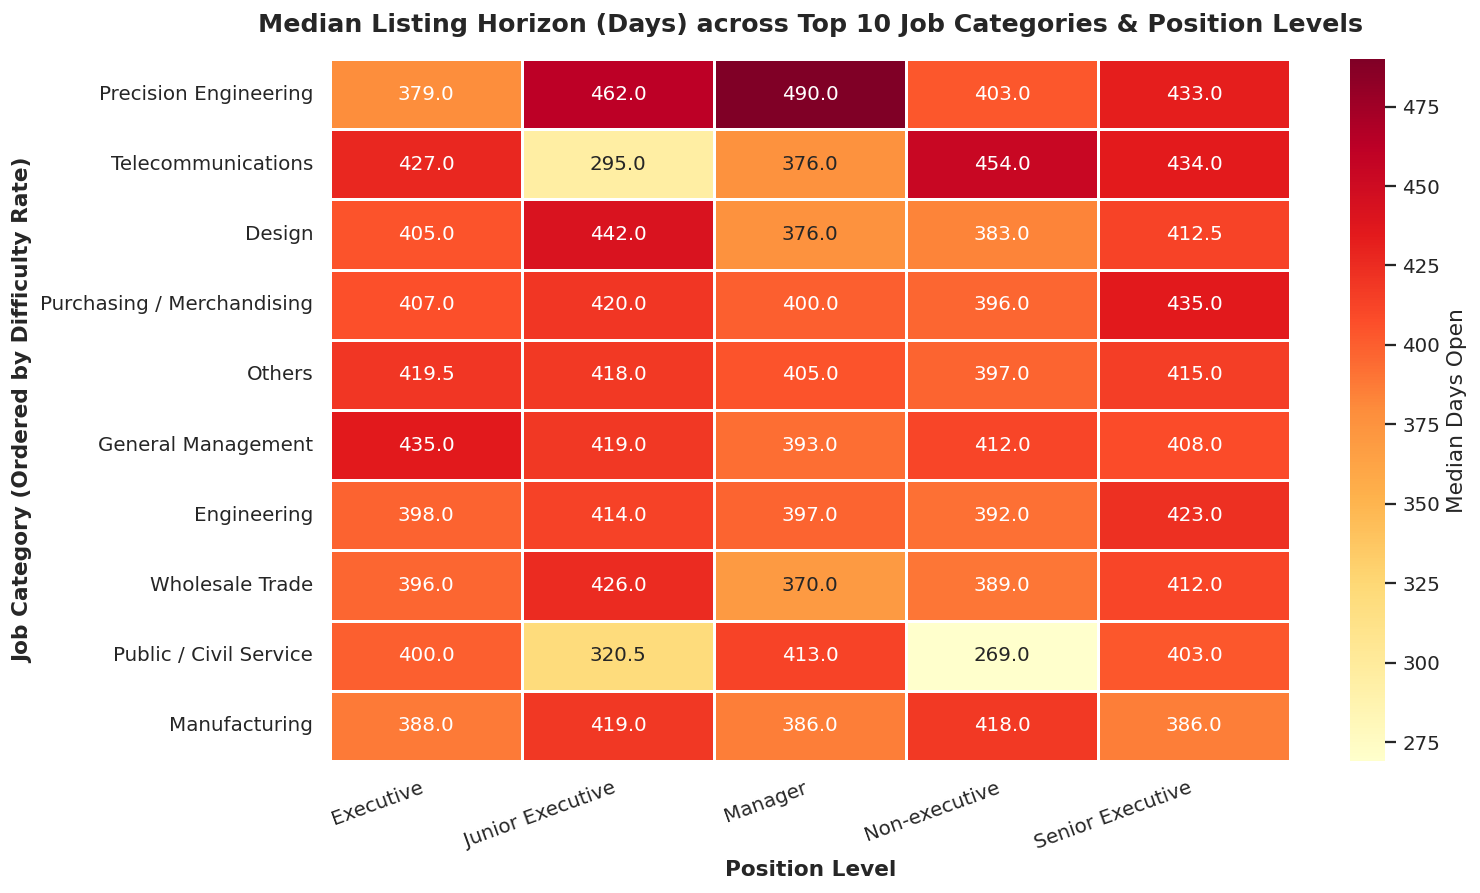

In [12]:
### Visualisation 3B Code (Category vs Position Level)
plt.figure(figsize=(12, 7))

# 1. Select top 10 categories & filter dataset
top_10_categories = top_cats["primary_category"].head(10).tolist()
df_pos = df[df["primary_category"].isin(top_10_categories)]

# 2. Get top 5 position levels
top_positions = (
    df_pos["position_level_clean"]
    .value_counts()
    .drop("Unspecified", errors="ignore")
    .head(5)
    .index.tolist()
)
df_pos_filtered = df_pos[df_pos["position_level_clean"].isin(top_positions)]

# 3. Pivot Table: Category vs Position Level -> Median Posting Duration
pivot_pos = df_pos_filtered.pivot_table(
    index="primary_category",
    columns="position_level_clean",
    values="posting_duration",
    aggfunc="median",
).reindex(top_10_categories)

# 4. Format annotations safely (NaN -> 'N/A')
if hasattr(pivot_pos, "map"):
    annot_pos = pivot_pos.map(
        lambda v: f"{v:.1f}" if pd.notnull(v) and v > 0 else "N/A"
    )
else:
    annot_pos = pivot_pos.applymap(
        lambda v: f"{v:.1f}" if pd.notnull(v) and v > 0 else "N/A"
    )

# 5. Render Heatmap
sns.heatmap(
    pivot_pos,
    annot=annot_pos,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Median Days Open"},
    mask=pivot_pos.isna(),
)

plt.title(
    "Median Listing Horizon (Days) across Top 10 Job Categories & Position Levels",
    fontweight="bold",
    pad=15,
)
plt.xlabel("Position Level", fontweight="bold")
plt.ylabel("Job Category (Ordered by Difficulty Rate)", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## <span style="color:#007acc;">📊 Visualisation 4: Hierarchical Composition Across All Top 10 Categories</span>

<div style="background-color: #f0f9ff; border-left: 5px solid #0284c7; padding: 14px; border-radius: 6px; margin-bottom: 14px; box-shadow: 0 1px 2px rgba(0,0,0,0.05);">
  <b style="color: #0369a1; font-size: 1.1em;">🔍 Visual Structure & Ordering</b>
  <ul style="margin-top: 6px; color: #1e293b; padding-left: 20px;">
    <li><b>Strict Category Rank (#1 to #10):</b> Subplots are arranged in <b>descending order of recruitment difficulty rate (%)</b>, starting from the single most hard-to-fill sector down to the 10th.</li>
    <li><b>Complete Position Level Coverage:</b> Displays <b>all available position levels</b> present within each category along the x-axis without truncation.</li>
    <li><b>100% Employment Type Breakdown:</b> Each stacked bar represents the <b>100% percentage composition of all available employment commitments</b> (<i>Permanent</i>, <i>Full Time</i>, <i>Contract</i>, <i>Flexi-work</i>, <i>Part Time</i>, <i>Temporary</i>) for that specific category and position level.</li>
  </ul>
</div>


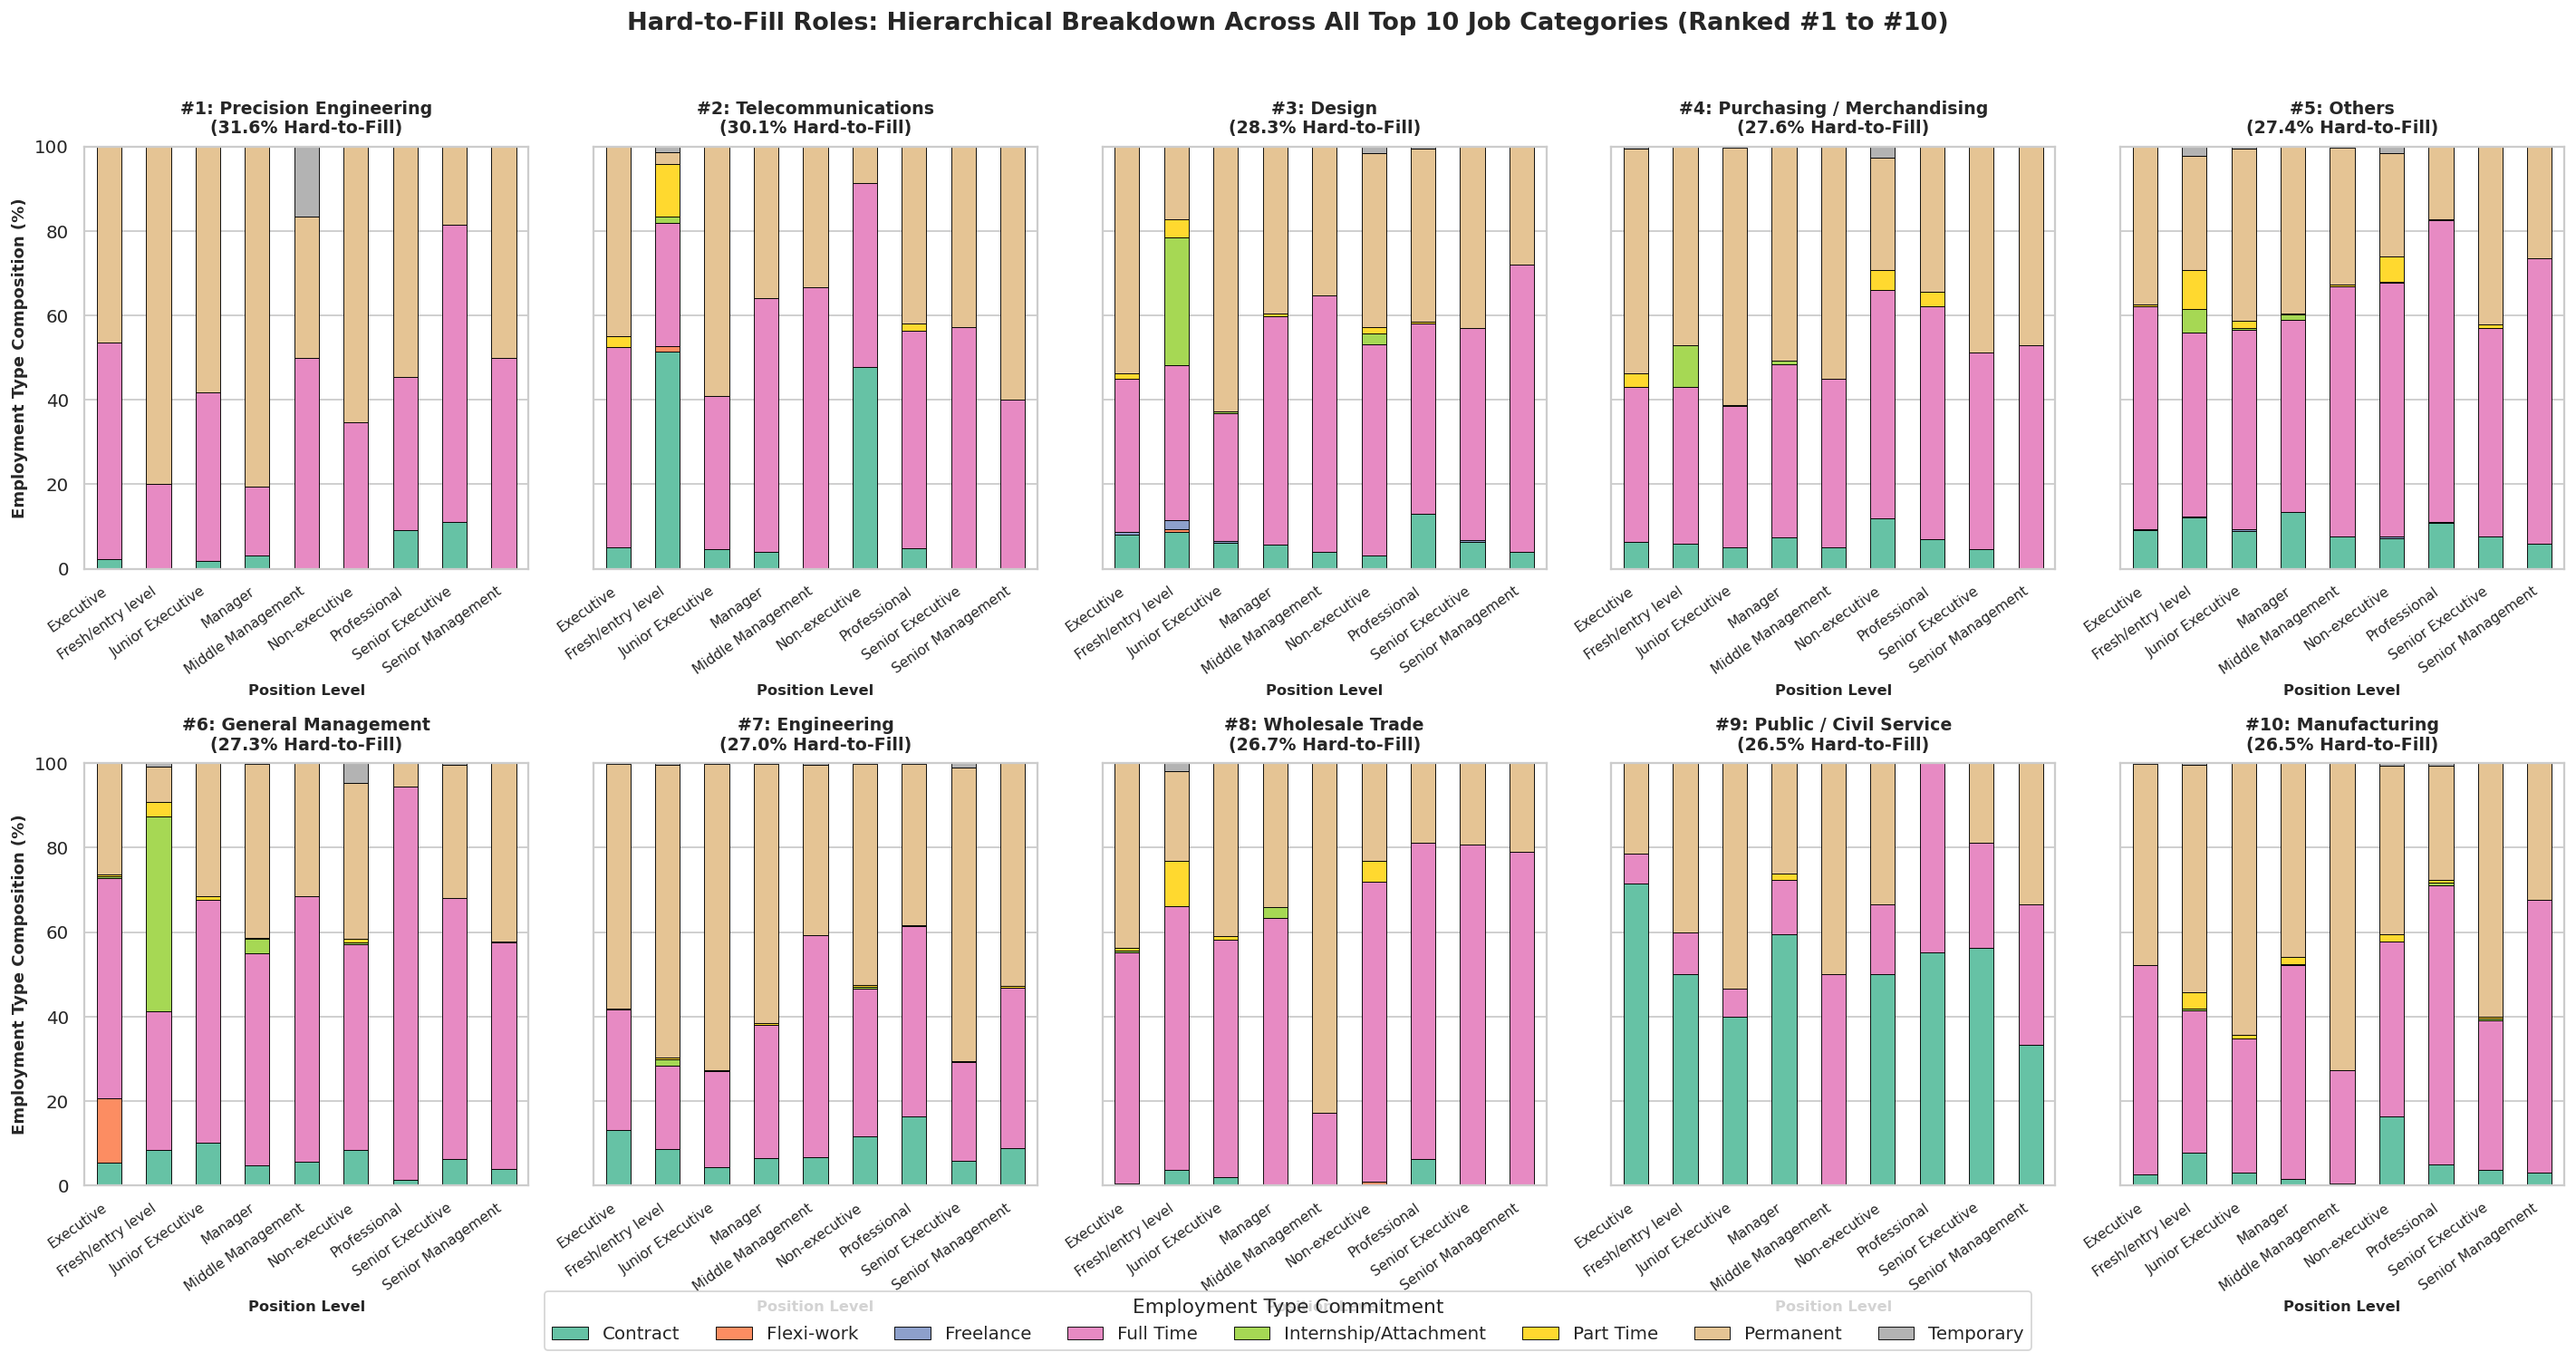

📊 COMPLETE HIERARCHICAL DRILL-DOWN TABLE (%)
employmentTypes                            Contract Flexi-work Freelance  \
primary_category      position_level_clean                                 
Precision Engineering Executive                2.3%       0.0%      0.0%   
                      Fresh/entry level        0.0%       0.0%      0.0%   
                      Junior Executive         1.8%       0.0%      0.0%   
                      Manager                  3.2%       0.0%      0.0%   
                      Middle Management        0.0%       0.0%      0.0%   
...                                             ...        ...       ...   
Manufacturing         Middle Management        0.5%       0.0%      0.0%   
                      Non-executive           16.3%       0.0%      0.0%   
                      Professional             4.9%       0.0%      0.0%   
                      Senior Executive         3.7%       0.0%      0.0%   
                      Senior Management    

In [15]:
### Visualisation 4 Code (2x5 Grid)
# --- CALCULATE TOP 10 CATEGORIES ORDERED FROM MOST TO LEAST HARD-TO-FILL ---
cat_summary = (
    df.groupby("primary_category")["is_hard_to_fill"]
    .agg(["count", "mean"])
    .reset_index()
)
cat_summary["difficulty_pct"] = cat_summary["mean"] * 100

top_cats_ordered = (
    cat_summary[cat_summary["count"] >= 5]
    .sort_values(by="difficulty_pct", ascending=False)
    .head(10)
)
top_10_categories_ordered = top_cats_ordered["primary_category"].tolist()

df_htf = df[df["is_hard_to_fill"] == True].copy()
df_htf_filtered = df_htf[
    df_htf["primary_category"].isin(top_10_categories_ordered)
]

# --- FACETED 100% STACKED BAR CHART GENERATION (2x5 GRID) ---
fig, axes = plt.subplots(2, 5, figsize=(22, 11), sharey=True)
axes = axes.flatten()

all_emp_types = sorted(df_htf_filtered["employmentTypes"].dropna().unique())
colors = sns.color_palette("Set2", len(all_emp_types))
color_map = dict(zip(all_emp_types, colors))

for idx, cat in enumerate(top_10_categories_ordered):
    ax = axes[idx]
    cat_data = df_htf_filtered[df_htf_filtered["primary_category"] == cat]

    # Include ALL available position levels present in this category
    ct = pd.crosstab(
        cat_data["position_level_clean"], cat_data["employmentTypes"]
    )

    for et in all_emp_types:
        if et not in ct.columns:
            ct[et] = 0
    ct = ct[all_emp_types]

    row_sums = ct.sum(axis=1)
    ct_pct = ct.div(row_sums.replace(0, 1), axis=0) * 100

    rank = idx + 1
    # Extract scalar float value using [0]
    pct_val = top_cats_ordered[
        top_cats_ordered["primary_category"] == cat
    ]["difficulty_pct"].values[0]

    ct_pct.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[color_map[col] for col in ct_pct.columns],
        edgecolor="black",
        linewidth=0.5,
        legend=False,
    )

    ax.set_title(
        f"#{rank}: {cat}\n({pct_val:.1f}% Hard-to-Fill)",
        fontweight="bold",
        fontsize=10.5,
        pad=8,
    )
    ax.set_xlabel("Position Level", fontweight="bold", fontsize=9)
    if idx % 5 == 0:
        ax.set_ylabel(
            "Employment Type Composition (%)", fontweight="bold", fontsize=10
        )
    else:
        ax.set_ylabel("")
    ax.set_ylim(0, 100)
    ax.set_xticklabels(
        ax.get_xticklabels(), rotation=35, ha="right", fontsize=8.5
    )

# Fixed: Extract legend handles & labels from individual subplot axes[0]
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Employment Type Commitment",
    bbox_to_anchor=(0.5, -0.02),
    loc="lower center",
    ncols=len(all_emp_types),
    fontsize=11,
    title_fontsize=12,
    frameon=True,
)

plt.suptitle(
    "Hard-to-Fill Roles: Hierarchical Breakdown Across All Top 10 Job Categories (Ranked #1 to #10)",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Print detailed summary
print("==================================================")
print("📊 COMPLETE HIERARCHICAL DRILL-DOWN TABLE (%)")
print("==================================================")
grouped_summary = (
    df_htf_filtered.groupby(
        ["primary_category", "position_level_clean", "employmentTypes"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(top_10_categories_ordered, level=0)
)
grouped_pct = grouped_summary.div(grouped_summary.sum(axis=1), axis=0) * 100
print(grouped_pct.round(1).astype(str) + "%")

# <span style="color:#007acc; font-family:Helvetica;">🏁 Presentation Summary & Strategic Takeaways</span>
### <span style="color:#555555;">Predicting Role Difficulty in the Singapore Job Market (`SGJobData.csv`)</span>

---

<div style="background: linear-gradient(135deg, #f0f9ff 0%, #e0f2fe 100%); border-left: 6px solid #0284c7; padding: 14px; border-radius: 8px; margin-bottom: 20px;">
  <h3 style="color:#0369a1; margin-top:0;">📌 Executive Conclusion</h3>
  <p style="font-size: 1.05em; color: #1e293b;">
    By standardising nested JSON categories and position levels, calculating monthly salary benchmarks, and evaluating active posting horizons from MyCareersFuture data, we successfully isolated the primary drivers of recruitment friction in Singapore.
  </p>
</div>

---


### <span style="color:#334155;">🔑 Core Findings & Evidence</span>

| Analytical Dimension | Empirical Data Findings | Strategic Business Significance |
| :--- | :--- | :--- |
| **Data Engineering** | Unnested JSON categories and position levels (`positionLevels`), standardising extreme outliers into valid monthly benchmarks. | Guarantees robust, un-biased compensation and seniority benchmarking across all sectors. |
| **Industry Bottlenecks** | Talent acquisition friction is heavily clustered in specialized technical sectors (*IT*, *Engineering*, *Health/Environment*). | Directs agency headhunting focus to high-demand, talent-scarce industries. |
| **Salary & Wage Dynamics** | Posted monthly salary medians for Hard-to-Fill roles currently mirror Standard Fill roles across most sectors (*Precision Engineering*, *Engineering*). | Exposes employer salary under-compensation; offering a **dedicated wage premium** is necessary to break hiring bottlenecks. |
| **Position Level Impact** | Recruitment delays are concentrated in **Senior Executive**, **Lead Specialist**, and **Managerial** position levels rather than entry-level roles. | Indicates that skill scarcity combined with unadjusted pay scales drives extended listing horizons (> 30 days). |

---

### <span style="color:#334155;">🎯 Strategic Recommendations</span>

<div style="display: flex; gap: 15px; margin-top: 15px;">

<div style="flex: 1; background-color: #fffbe3; border-left: 5px solid #d97706; padding: 14px; border-radius: 8px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
  <h4 style="color: #b45309; margin-top:0;">🏢 For Recruitment Agencies & Employers</h4>
  <ul style="color: #451a03; padding-left: 20px;">
    <li><b>Offer Wage Premiums:</b> Advise employers to offer a 15–20% salary premium for specialized Senior Executive and Managerial roles exceeding 30 days open.</li>
    <li><b>Proactive Pipeline Building:</b> Focus active headhunting resources on technical position levels rather than depending on passive portal postings.</li>
  </ul>
</div>

<div style="flex: 1; background-color: #f0fdf4; border-left: 5px solid #16a34a; padding: 14px; border-radius: 8px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
  <h4 style="color: #15803d; margin-top:0;">🎓 For Job Seekers</h4>
  <ul style="color: #052e16; padding-left: 20px;">
    <li><b>Targeted Upskilling:</b> Focus professional development on mid-to-senior technical competencies to command higher starting salary premiums.</li>
    <li><b>Realistic Search Timelines:</b> Anticipate longer recruitment cycles (30–60 days) when applying for Senior Executive and Managerial vacancies.</li>
  </ul>
</div>

</div>

---

<div style="background-color: #fdf2f8; border-left: 5px solid #db2777; padding: 14px; border-radius: 8px; margin-top: 20px;">
  <b style="color: #9d174d; font-size: 1.1em;">🚀 Future ML Extension</b><br>
  <span style="color: #831843;">Deploy a Predictive Machine Learning Classifier (e.g. <b>Random Forest / XGBoost</b>) using salary midpoint, unnested position levels, and job title embeddings to forecast <b>Hard-to-Fill Probabilities</b> for new listings in real-time.</span>
</div>
